In [ ]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("ccmusic-database/music_genre")

In [4]:
train_df = ds["train"].to_pandas()

In [9]:
ds["train"][0]


{'mel': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=496x369>,
 'cqt': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=496x369>,
 'chroma': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=496x369>,
 'fst_level_label': 1,
 'sec_level_label': 4,
 'thr_level_label': 6}

In [14]:
ds["train"]


Dataset({
    features: ['mel', 'cqt', 'chroma', 'fst_level_label', 'sec_level_label', 'thr_level_label'],
    num_rows: 29100
})

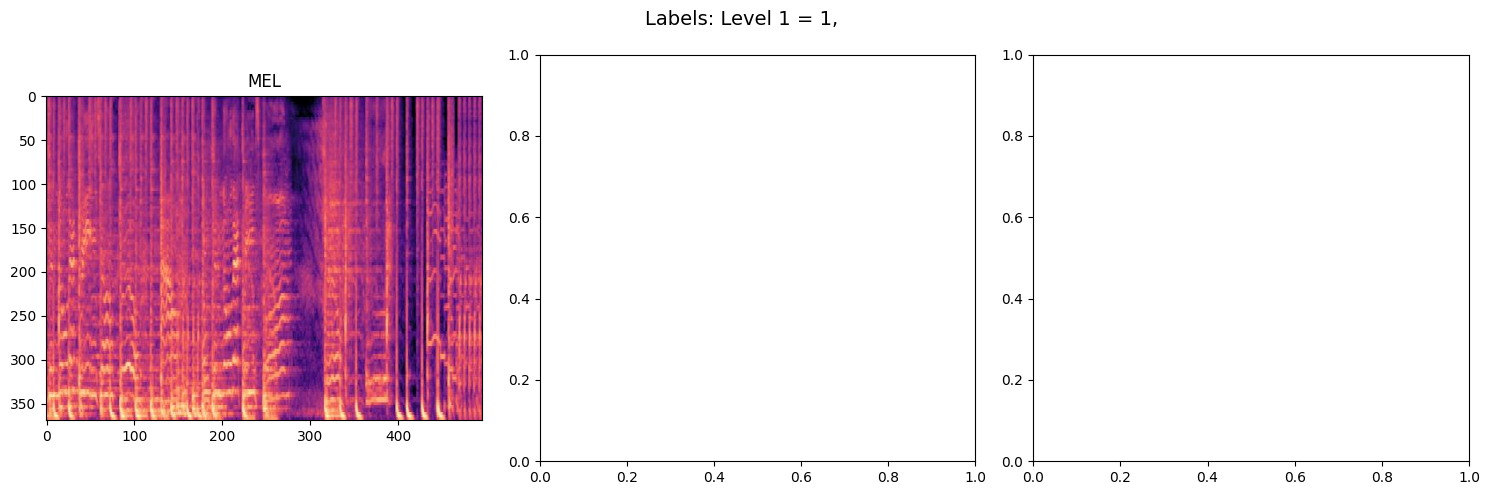

In [13]:
import matplotlib.pyplot as plt
example = ds["train"][4]
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for ax, (key, image) in zip(axs, [(k, example[k]) for k in ['mel']]):
    ax.imshow(image)
    ax.set_title(key.upper())
    #ax.axis('off')

# show labels in the plot title or below
fig.suptitle(f"Labels: Level 1 = {example['fst_level_label']}, "
             #f"Level 2 = {example['sec_level_label']}, "
             #f"Level 3 = {example['thr_level_label']}", 
             ,fontsize=14)

plt.tight_layout()
plt.show()

In [25]:
from pathlib import Path
import os
num_songs = 0
root = r"P:\datasets\geenres\ismir04_genre\ismir04_genre\audio\training\metal"
for path, subdirs, files in os.walk(root):
    for name in files:
        #print(os.path.join(path, name))
        num_songs += 1
print(num_songs)

29


In [27]:
def get_num_songs(root):
    num_songs = 0
    for path, subdirs, files in os.walk(root):
        for name in files:
            #print(os.path.join(path, name))
            num_songs += 1
    print(num_songs)
    return num_songs


In [ ]:
metal_train = get_num_songs(r"P:\datasets\geenres\ismir04_genre\ismir04_genre\audio\training\metal")
metal_eval = get_num_songs(r"P:\datasets\geenres\ismir04_genre\ismir04_genre\audio\evaluation\metal")

29
29


: 

# 1517 artists dataset

In [5]:
import os
num_songs = 0
root = r"P:\datasets\geenres\1517\1517\1517-Artists"
for path, subdirs, files in os.walk(root):
    if len(subdirs) != 0:
        print(subdirs)
    for name in files:
        #print(os.path.join(path, name))
        num_songs += 1
print(num_songs)

['Alternative_and_Punk', 'Blues', 'Childrenss', 'Classical', 'Comedy_and_Spoken_Word', 'Country', 'Easy_Listening_and_Vocals', 'Electronic_and_Dance', 'Folk', 'Hip-Hop', 'Jazz', 'Latin', 'New_Age', 'Reggae', 'Religious', 'Rock_and_Pop', 'R_and_B_and_Soul', 'Soundtracks_and_More', 'World']
3181


In [14]:
def clean_genres(keys, dictionary):
    for key in keys:
        if key in dictionary:
            del dictionary[key]
    return dictionary

In [18]:
from os import listdir
from os.path import isfile, join
genre_distributions = {}
subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]
for folder in subfolders:
    onlyfiles = [f for f in listdir(folder) if isfile(join(folder, f))]
    genre_distributions[folder.split("\\")[-1]] = len(onlyfiles)
genre_distributions = clean_genres(['Childrenss','Religious', 'Comedy_and_Spoken_Word' ], genre_distributions)

In [19]:
genre_distributions

{'Alternative_and_Punk': 182,
 'Blues': 186,
 'Classical': 125,
 'Country': 187,
 'Easy_Listening_and_Vocals': 175,
 'Electronic_and_Dance': 164,
 'Folk': 185,
 'Hip-Hop': 155,
 'Jazz': 177,
 'Latin': 163,
 'New_Age': 175,
 'Reggae': 172,
 'Rock_and_Pop': 182,
 'R_and_B_and_Soul': 175,
 'Soundtracks_and_More': 150,
 'World': 158}

In [38]:
genres_sorted = {k: v for k, v in sorted(genre_distributions.items(), key=lambda item: item[1])}
genres_sorted

{'Classical': 125,
 'Soundtracks_and_More': 150,
 'Hip-Hop': 155,
 'World': 158,
 'Latin': 163,
 'Electronic_and_Dance': 164,
 'Reggae': 172,
 'Easy_Listening_and_Vocals': 175,
 'New_Age': 175,
 'R_and_B_and_Soul': 175,
 'Jazz': 177,
 'Alternative_and_Punk': 182,
 'Rock_and_Pop': 182,
 'Folk': 185,
 'Blues': 186,
 'Country': 187}

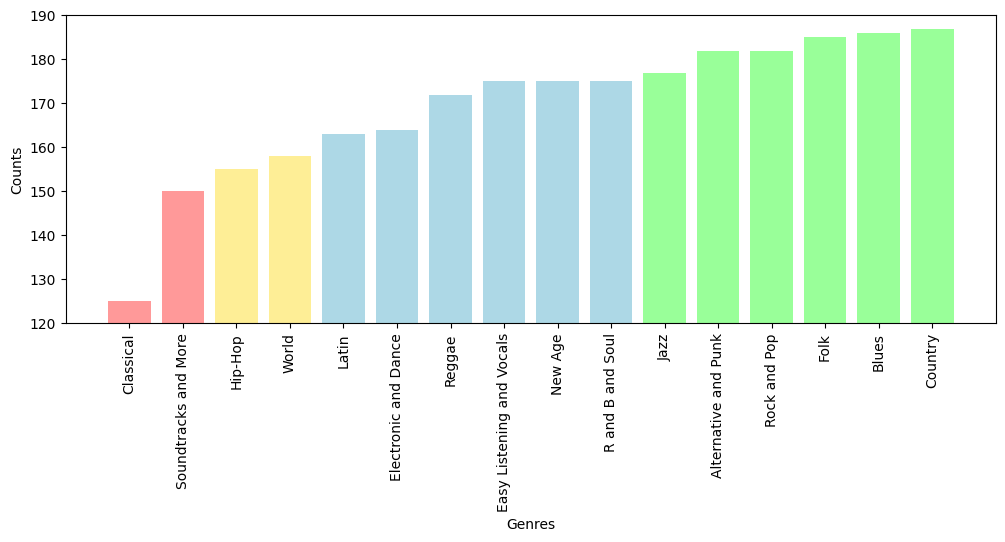

In [47]:
import matplotlib.pyplot as plt
from matplotlib import *
names = [name.replace("_", " ") for name in list(genres_sorted.keys())]
values = list(genres_sorted.values())
pastel_red = '#ff9999'
pastel_green = '#99ff99'
pastel_yellow = '#feee96'
pastel_blue = '#add8e6'
colors = []
for count in values:
    if count > 175:
        colors.append(pastel_green)
    elif count >160:
        colors.append(pastel_blue)
    elif count > 150:
        colors.append(pastel_yellow)
    else:
        colors.append(pastel_red)
plt.figure(figsize=(12,4))
plt.bar(range(len(genre_distributions)),values, tick_label = names, color = colors)
plt.ylim(120, 190)
plt.xlabel("Genres")
plt.xticks(rotation = "vertical")
plt.ylabel("Counts")
plt.show()